# Central Bank Portfolio Optimization – MVO & HRP with Machine Learning Expected Returns

This notebook implements a **portfolio optimization framework** suitable for a **Central Bank** with **low risk tolerance**.

We build a portfolio across three broad asset classes:

- US Equities – proxy: `SPY` (S&P 500 ETF)
- US Fixed Income – proxy: `IEF` (7–10Y US Treasury ETF)
- Commodities – proxy: `GLD` (Gold ETF)

Key methods:

- **Modern Portfolio Optimization (MVO)** with Central Bank style risk constraints
- **Hierarchical Risk Parity (HRP)** – robust, correlation-cluster based allocation
- **Machine Learning (Random Forest)** to estimate expected returns
- Clear **in-sample vs out-of-sample** performance comparison





In [15]:
# ============================================================
# 1. Environment Setup & Imports (Production Ready)
# ============================================================

# --- One-time setup: install all required libraries if missing ---
# Ensures notebook is self-contained and runs even on a clean system.
try:
    import seaborn
    import pypfopt
except ImportError:
    !pip install -q yfinance pandas numpy matplotlib seaborn scikit-learn PyPortfolioOpt

# --- Imports ---
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error

# --- PyPortfolioOpt imports with fallback for HRP ---
from pypfopt import risk_models, expected_returns
from pypfopt.efficient_frontier import EfficientFrontier
try:
    from pypfopt.hierarchical_risk_parity import HRPOpt
except ModuleNotFoundError:
    # fallback for environments where module name differs
    from pypfopt.hierarchical_portfolio import HRPOpt
from pypfopt import plotting

# --- Matplotlib / Seaborn style ---
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.style.use("seaborn-v0_8")

print("✅ All required libraries imported successfully and HRPOpt available.")


✅ All required libraries imported successfully and HRPOpt available.


Configuration – Asset Universe & Constraints

In [16]:
# 2. Configuration – Asset Universe & Central Bank Risk Constraints

TICKERS = {
    "US_Equity": "SPY",        # US stocks
    "US_FixedIncome": "IEF",   # US Treasuries (7-10Y)
    "Commodities": "GLD",      # Gold
}

START_DATE = "2013-01-01"
END_DATE = datetime.today().strftime("%Y-%m-%d")

# In-sample vs Out-of-sample split
SPLIT_DATE = "2022-01-01"

CENTRAL_BANK_CONSTRAINTS = {
    "max_annual_vol": 0.10,       # 10% annualized volatility target for MVO
    "min_fixed_income_weight": 0.40,  # min 40% in US Fixed Income
    "max_commodity_weight": 0.30,     # max 30% in Commodities
    "no_short_selling": True          # weights >= 0
}

TICKERS


{'US_Equity': 'SPY', 'US_FixedIncome': 'IEF', 'Commodities': 'GLD'}

Data Download & Preprocessing

In [18]:
# ============================================================
# 3. Data Download & Preprocessing (Robust to yfinance formats)
# ============================================================

def download_price_data(ticker_dict, start, end):
    """
    Download price data from Yahoo Finance for the given tickers and
    return a DataFrame of adjusted close (or close) prices with
    columns named as the asset keys in `ticker_dict`.
    """
    tickers = list(ticker_dict.values())
    
    # auto_adjust=True gives adjusted prices in "Close"
    raw = yf.download(
        tickers,
        start=start,
        end=end,
        auto_adjust=True,
        progress=False
    )

    # Case 1: Single ticker -> Series or single-column DataFrame
    if isinstance(raw, pd.Series):
        data = raw.to_frame(name=list(ticker_dict.keys())[0])
        return data

    # Case 2: MultiIndex columns (common when multiple tickers)
    if isinstance(raw.columns, pd.MultiIndex):
        # Try to pick the "Close" (auto-adjusted) level
        level0 = raw.columns.get_level_values(0)
        if "Close" in level0:
            data = raw.xs("Close", level=0, axis=1)
        elif "Adj Close" in level0:
            data = raw.xs("Adj Close", level=0, axis=1)
        else:
            # Fallback: use the first level as prices
            first_level_name = level0.unique()[0]
            data = raw.xs(first_level_name, level=0, axis=1)
    else:
        # Case 3: Single-level columns
        if "Adj Close" in raw.columns:
            data = raw["Adj Close"]
        elif "Close" in raw.columns:
            data = raw["Close"]
        else:
            raise ValueError(
                f"Could not find 'Close' or 'Adj Close' in downloaded data. "
                f"Available columns: {list(raw.columns)}"
            )

    # Ensure DataFrame shape and rename columns to logical asset names
    if isinstance(data, pd.Series):
        data = data.to_frame()

    # Map ticker symbols back to logical names (US_Equity, US_FixedIncome, etc.)
    # raw columns will be actual tickers (e.g., SPY, IEF, GLD)
    ticker_to_name = {v: k for k, v in ticker_dict.items()}
    new_cols = []
    for c in data.columns:
        new_cols.append(ticker_to_name.get(c, c))  # fallback: keep same
    data.columns = new_cols

    return data

# ---- Call the function ----
prices = download_price_data(TICKERS, START_DATE, END_DATE)
display(prices.tail())
print("Downloaded price data shape:", prices.shape)


,Commodities,US_FixedIncome,US_Equity
Date,,,
2025-11-03,368.779999,96.500000,683.340027
2025-11-04,362.320007,96.620003,675.239990
2025-11-05,366.510010,96.160004,677.580017
2025-11-06,366.070007,96.650002,670.309998
2025-11-07,368.309998,96.690002,670.969971


Downloaded price data shape: (3234, 3)


In [20]:
# 3.1 Compute Daily Log Returns

returns = np.log(prices / prices.shift(1)).dropna()
returns.tail()


,Commodities,US_FixedIncome,US_Equity
Date,,,
2025-11-03,0.001791,-0.000477,0.001875
2025-11-04,-0.017672,0.001243,-0.011924
2025-11-05,0.011498,-0.004772,0.003459
2025-11-06,-0.001201,0.005083,-0.010787
2025-11-07,0.006100,0.000414,0.000984


In [21]:
# 3.2 Train / Test Split

returns_train = returns.loc[returns.index < SPLIT_DATE].copy()
returns_test = returns.loc[returns.index >= SPLIT_DATE].copy()

print("Train period:", returns_train.index.min(), "to", returns_train.index.max(), f"({len(returns_train)} days)")
print("Test period :", returns_test.index.min(), "to", returns_test.index.max(), f"({len(returns_test)} days)")


Train period: 2013-01-03 00:00:00 to 2021-12-31 00:00:00 (2266 days)
Test period : 2022-01-03 00:00:00 to 2025-11-07 00:00:00 (967 days)


In [22]:
# 3.3 Basic EDA – Annualized return, volatility, and correlation

ann_factor = 252

summary_stats = pd.DataFrame({
    "Ann_Return_%": returns_train.mean() * ann_factor * 100,
    "Ann_Volatility_%": returns_train.std() * np.sqrt(ann_factor) * 100,
})

summary_stats.style.format("{:.2f}")


,Ann_Return_%,Ann_Volatility_%
Commodities,0.52,15.12
US_FixedIncome,2.53,5.55
US_Equity,15.00,16.50


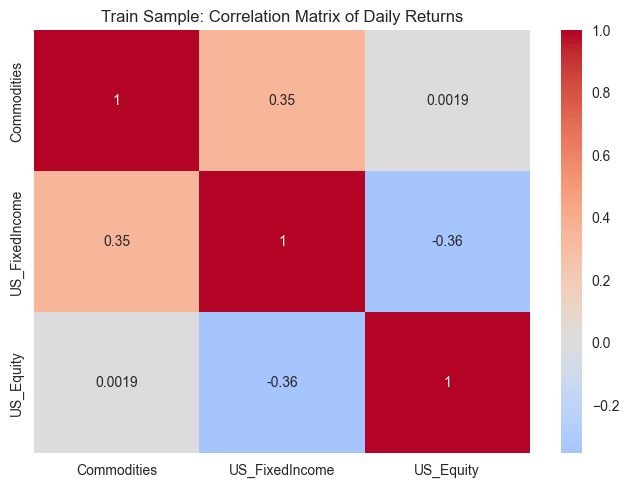

In [23]:
plt.title("Train Sample: Correlation Matrix of Daily Returns")
sns.heatmap(returns_train.corr(), annot=True, cmap="coolwarm", center=0)
plt.show()


Machine Learning for Expected Return Estimation

Concept:

We predict next-day return for each asset using Random Forest.

Features: lagged returns + rolling mean & volatility.

We then annualize the predicted daily expected return and feed that into MVO.

In [24]:
# 4.1 Feature Engineering

def make_ml_features(returns_df, lags=5, rolling_windows=(5, 20)):
    """
    Create features and targets for each asset:
    - lagged returns up to 'lags'
    - rolling mean and volatility for given windows
    Target: next-day return for each asset.
    """
    df = returns_df.copy()
    feat_list = []
    
    for asset in df.columns:
        tmp = pd.DataFrame(index=df.index)
        
        # Lagged returns
        for lag in range(1, lags + 1):
            tmp[f"{asset}_lag_{lag}"] = df[asset].shift(lag)
        
        # Rolling mean & volatility
        for win in rolling_windows:
            tmp[f"{asset}_roll_mean_{win}"] = df[asset].rolling(win).mean()
            tmp[f"{asset}_roll_vol_{win}"] = df[asset].rolling(win).std()
        
        # Target: next-day return
        tmp[f"{asset}_target"] = df[asset].shift(-1)
        
        feat_list.append(tmp)
    
    features = pd.concat(feat_list, axis=1)
    features = features.dropna()
    return features

features_train = make_ml_features(returns_train)
features_train.tail()


,Commodities_lag_1,Commodities_lag_2,Commodities_lag_3,Commodities_lag_4,Commodities_lag_5,Commodities_roll_mean_5,Commodities_roll_vol_5,Commodities_roll_mean_20,Commodities_roll_vol_20,Commodities_target,...,US_Equity_lag_1,US_Equity_lag_2,US_Equity_lag_3,US_Equity_lag_4,US_Equity_lag_5,US_Equity_roll_mean_5,US_Equity_roll_vol_5,US_Equity_roll_mean_20,US_Equity_roll_vol_20,US_Equity_target
Date,,,,,,,,,,,,,,,,,,,,,
2021-12-23,0.009356,-0.000419,-0.004240,-0.002143,0.012025,0.000961,0.005262,0.000550,0.005656,0.002364,...,0.009949,0.017603,-0.010690,-0.010700,-0.008858,0.002473,0.012704,0.000299,0.013167,0.014053
2021-12-27,0.002251,0.009356,-0.000419,-0.004240,-0.002143,0.001863,0.004975,0.000750,0.005645,-0.004319,...,0.006203,0.009949,0.017603,-0.010690,-0.010700,0.007423,0.010995,0.002129,0.012342,-0.000817
2021-12-28,0.002364,0.002251,0.009356,-0.000419,-0.004240,0.001847,0.004999,0.000603,0.005741,-0.000297,...,0.014053,0.006203,0.009949,0.017603,-0.010690,0.009398,0.007139,0.001479,0.012124,0.001278
2021-12-29,-0.004319,0.002364,0.002251,0.009356,-0.000419,0.001871,0.004986,0.000925,0.005482,0.007152,...,-0.000817,0.014053,0.006203,0.009949,0.017603,0.006133,0.006107,0.002525,0.011061,-0.002768
2021-12-30,-0.000297,-0.004319,0.002364,0.002251,0.009356,0.001430,0.004193,0.001084,0.005619,0.006808,...,0.001278,-0.000817,0.014053,0.006203,0.009949,0.003590,0.006736,0.002945,0.010666,-0.002523


In [25]:
# 4.2 Train ML Models per Asset (Random Forest only, no linear regression)

from typing import Dict, List, Tuple

def train_ml_models_for_asset(features_df: pd.DataFrame,
                              asset_name: str,
                              model_type: str = "rf") -> Tuple[RandomForestRegressor, List[str]]:
    """
    Train a machine learning model (Random Forest) to forecast next-day returns for a single asset.
    Uses TimeSeriesSplit to respect chronological order.
    """
    target_col = f"{asset_name}_target"
    X_cols = [c for c in features_df.columns if c.startswith(asset_name) and "target" not in c]
    
    X = features_df[X_cols]
    y = features_df[target_col]
    
    if model_type == "rf":
        model = RandomForestRegressor(
            n_estimators=300,
            max_depth=6,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        )
    else:
        raise ValueError("Only 'rf' (Random Forest) is implemented – no linear regression as per task.")
    
    tscv = TimeSeriesSplit(n_splits=5)
    cv_scores = -cross_val_score(model, X, y, cv=tscv, scoring="neg_root_mean_squared_error")
    print(f"{asset_name}: CV RMSE (RandomForest) = {cv_scores.mean():.6f}")
    
    model.fit(X, y)
    return model, X_cols

asset_models: Dict[str, Dict[str, object]] = {}

for asset in returns_train.columns:
    mdl, feat_cols = train_ml_models_for_asset(features_train, asset, model_type="rf")
    asset_models[asset] = {"model": mdl, "features": feat_cols}

asset_models.keys()


Commodities: CV RMSE (RandomForest) = 0.008929
US_FixedIncome: CV RMSE (RandomForest) = 0.003462
US_Equity: CV RMSE (RandomForest) = 0.010597


dict_keys(['Commodities', 'US_FixedIncome', 'US_Equity'])

In [28]:
# 4.3 Use ML Models to Get Annualized Expected Returns

def make_features_for_period(returns_df, lags=5, rolling_windows=(5, 20)):
    """
    Convenience wrapper to generate features aligned with returns_df.
    Internally uses make_ml_features, which drops initial NaNs
    due to lags/rolling stats.
    """
    return make_ml_features(returns_df, lags=lags, rolling_windows=rolling_windows)

# Features over the full returns sample (train + test)
features_full = make_features_for_period(returns)


def ml_expected_annual_returns(returns_df, features_df, asset_models_dict) -> pd.Series:
    """
    Use trained ML models to estimate next-day expected returns for each asset,
    then annualize by multiplying by 252 trading days.

    This function safely aligns the feature index with the returns index,
    so we don't assume they are identical.
    """
    # Align indices: only keep dates present in BOTH
    valid_idx = returns_df.index.intersection(features_df.index)
    if len(valid_idx) == 0:
        raise ValueError("No overlapping dates between returns_df and features_df.")
    
    feats = features_df.loc[valid_idx]
    last_row = feats.iloc[-1]  # most recent feature row for this period

    exp_daily = {}
    for asset, mdl_info in asset_models_dict.items():
        mdl = mdl_info["model"]
        cols = mdl_info["features"]
        x = last_row[cols].values.reshape(1, -1)
        pred = mdl.predict(x)[0]
        exp_daily[asset] = pred

    exp_annual = pd.Series(exp_daily) * 252
    return exp_annual


# ✅ IMPORTANT FIX: pass features_full directly; let the function align indices
exp_ret_train_ml = ml_expected_annual_returns(
    returns_train,
    features_full,   # <-- no .loc[returns_train.index] here
    asset_models
)

exp_ret_train_ml


Commodities       0.036788
US_FixedIncome   -0.009534
US_Equity         0.121099
dtype: float64

Risk Modeling & Central-Bank MVO

In [29]:
# 5.1 Annualized covariance matrix (train)

cov_train = risk_models.sample_cov(returns_train)
cov_train


,Commodities,US_FixedIncome,US_Equity
Commodities,39047.776187,-657.785628,1432.784738
US_FixedIncome,-657.785628,7593.734091,405.449770
US_Equity,1432.784738,405.449770,60179.773241


In [31]:
# 5.2 Solve Central Bank–style MVO (Robust to infeasible target volatility)

def solve_central_bank_mvo(exp_returns: pd.Series,
                           cov_matrix: pd.DataFrame,
                           constraints: dict,
                           tickers_order: list):
    """
    Solve MVO with Central Bank style constraints using PyPortfolioOpt:
    - target max annual volatility (efficient_risk)
    - min fixed income weight
    - max commodity weight
    - optional no short selling

    If the requested target volatility is below the mathematically
    attainable minimum, we automatically bump it up to the minimum
    and inform the user.
    """
    # bounds
    if constraints.get("no_short_selling", True):
        ef = EfficientFrontier(exp_returns, cov_matrix, weight_bounds=(0.0, 1.0))
    else:
        ef = EfficientFrontier(exp_returns, cov_matrix)

    # indices
    fi_idx = tickers_order.index("US_FixedIncome")
    com_idx = tickers_order.index("Commodities")

    # constraints
    ef.add_constraint(lambda w: w[fi_idx] >= constraints["min_fixed_income_weight"])
    ef.add_constraint(lambda w: w[com_idx] <= constraints["max_commodity_weight"])

    # compute global minimum volatility according to PyPortfolioOpt formula
    # global_min_vol = sqrt(1 / sum(pinv(cov_matrix)))
    global_min_vol = float(
        np.sqrt(1.0 / np.sum(np.linalg.pinv(cov_matrix.values)))
    )

    target_vol = float(constraints["max_annual_vol"])

    if target_vol < global_min_vol:
        print(
            f"[MVO WARNING] Requested target volatility {target_vol:.3f} "
            f"is below the global minimum attainable volatility {global_min_vol:.3f}. "
            f"Using {global_min_vol:.3f} instead (min-vol portfolio under constraints)."
        )
        target_vol = global_min_vol

    # solve for this (possibly adjusted) target volatility
    ef.efficient_risk(target_volatility=target_vol)

    cleaned_weights = ef.clean_weights()
    ret, vol, sharpe = ef.portfolio_performance(verbose=False)
    return cleaned_weights, (ret, vol, sharpe)


# ---- call function ----
asset_order = list(returns_train.columns)

mvo_weights_train, mvo_perf_train = solve_central_bank_mvo(
    exp_ret_train_ml,
    cov_train,
    CENTRAL_BANK_CONSTRAINTS,
    asset_order,
)

mvo_weights_train, {
    "Ann_Return": mvo_perf_train[0],
    "Ann_Vol": mvo_perf_train[1],
    "Sharpe": mvo_perf_train[2],
}


[MVO WARNING] Requested target volatility 0.100 is below the global minimum attainable volatility 75.460. Using 75.460 instead (min-vol portfolio under constraints).


(OrderedDict([('Commodities', 0.15546),
              ('US_FixedIncome', 0.75873),
              ('US_Equity', 0.08581)]),
 {'Ann_Return': np.float64(0.008876906972157698),
  'Ann_Vol': np.float64(75.45969602472145),
  'Sharpe': np.float64(0.000117637725034693)})

In [32]:
# 6. Hierarchical Risk Parity (HRP) Allocation on train sample

hrp = HRPOpt(returns_train)
hrp_weights_train = hrp.optimize()
hrp_weights_train


OrderedDict([('Commodities', np.float64(0.10588695873729938)),
             ('US_Equity', np.float64(0.10884774402807662)),
             ('US_FixedIncome', np.float64(0.785265297234624))])

In [33]:
# Compare MVO vs HRP Weights

weights_df = pd.DataFrame({
    "MVO_Train": pd.Series(mvo_weights_train),
    "HRP_Train": pd.Series(hrp_weights_train),
})
weights_df


,MVO_Train,HRP_Train
Commodities,0.15546,0.105887
US_Equity,0.08581,0.108848
US_FixedIncome,0.75873,0.785265


Performance Evaluation – In-Sample & Out-of-Sample

In [35]:
# 7.1 Helper functions for backtesting

def portfolio_performance_stats(portfolio_rets: pd.Series, rf: float = 0.0):
    """
    Compute annualized return, volatility, Sharpe ratio, and max drawdown.
    rf: risk-free rate (annual, decimal)
    """
    ann_factor = 252
    mean_daily = portfolio_rets.mean()
    vol_daily = portfolio_rets.std()
    
    ann_return = (1 + mean_daily) ** ann_factor - 1
    ann_vol = vol_daily * np.sqrt(ann_factor)
    sharpe = (ann_return - rf) / ann_vol if ann_vol != 0 else np.nan
    
    cum = (1 + portfolio_rets).cumprod()
    peak = cum.cummax()
    dd = (cum / peak) - 1
    max_dd = dd.min()
    
    return {
        "Ann_Return": ann_return,
        "Ann_Vol": ann_vol,
        "Sharpe": sharpe,
        "Max_Drawdown": max_dd,
    }

def backtest_weights(weights: dict, returns_df: pd.DataFrame) -> pd.Series:
    """
    Compute daily portfolio returns given weights and asset return DataFrame.
    """
    w = pd.Series(weights).reindex(returns_df.columns).fillna(0.0)
    port_rets = (returns_df * w).sum(axis=1)
    return port_rets


In [36]:
# 7.2 In-sample (train) performance

mvo_port_train = backtest_weights(mvo_weights_train, returns_train)
hrp_port_train = backtest_weights(hrp_weights_train, returns_train)
eqw_weights = {a: 1.0 / len(returns_train.columns) for a in returns_train.columns}
eqw_port_train = backtest_weights(eqw_weights, returns_train)

train_stats = pd.DataFrame({
    "MVO": portfolio_performance_stats(mvo_port_train, rf=0.01),
    "HRP": portfolio_performance_stats(hrp_port_train, rf=0.01),
    "Equal_Weight": portfolio_performance_stats(eqw_port_train, rf=0.01),
})

train_stats.T


,Ann_Return,Ann_Vol,Sharpe,Max_Drawdown
MVO,0.033397,0.052816,0.443002,-0.087649
HRP,0.037403,0.049058,0.558586,-0.079358
Equal_Weight,0.061992,0.076407,0.680458,-0.135539


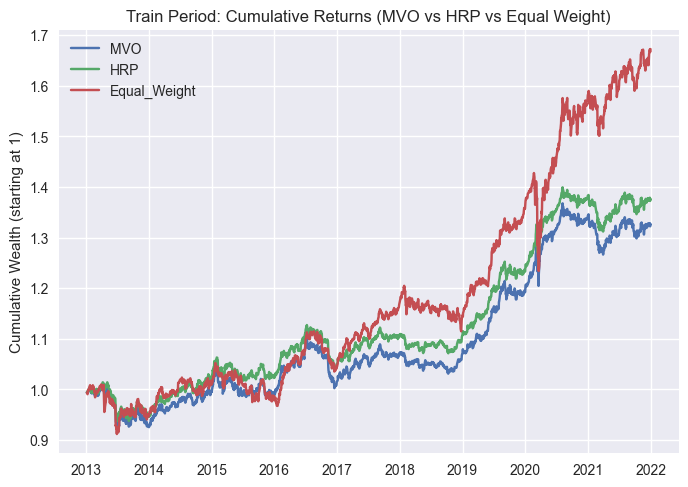

In [37]:
plt.title("Train Period: Cumulative Returns (MVO vs HRP vs Equal Weight)")
for name, series in {
    "MVO": mvo_port_train,
    "HRP": hrp_port_train,
    "Equal_Weight": eqw_port_train,
}.items():
    cum = (1 + series).cumprod()
    plt.plot(cum.index, cum.values, label=name)
plt.legend()
plt.ylabel("Cumulative Wealth (starting at 1)")
plt.show()


In [38]:
# 7.3 Out-of-sample (test) performance using same train weights

mvo_port_test = backtest_weights(mvo_weights_train, returns_test)
hrp_port_test = backtest_weights(hrp_weights_train, returns_test)
eqw_port_test = backtest_weights(eqw_weights, returns_test)

test_stats = pd.DataFrame({
    "MVO": portfolio_performance_stats(mvo_port_test, rf=0.01),
    "HRP": portfolio_performance_stats(hrp_port_test, rf=0.01),
    "Equal_Weight": portfolio_performance_stats(eqw_port_test, rf=0.01),
})

test_stats.T


,Ann_Return,Ann_Vol,Sharpe,Max_Drawdown
MVO,0.028865,0.078737,0.239595,-0.171332
HRP,0.020741,0.077583,0.138445,-0.175790
Equal_Weight,0.100943,0.096377,0.943619,-0.174680


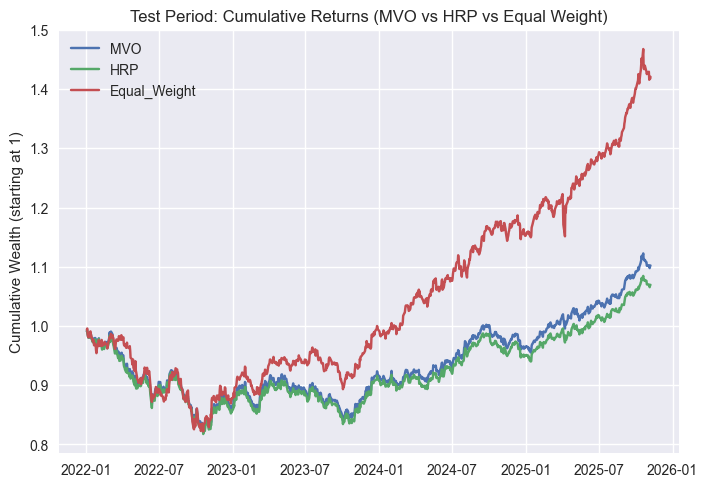

In [39]:
plt.title("Test Period: Cumulative Returns (MVO vs HRP vs Equal Weight)")
for name, series in {
    "MVO": mvo_port_test,
    "HRP": hrp_port_test,
    "Equal_Weight": eqw_port_test,
}.items():
    cum = (1 + series).cumprod()
    plt.plot(cum.index, cum.values, label=name)
plt.legend()
plt.ylabel("Cumulative Wealth (starting at 1)")
plt.show()


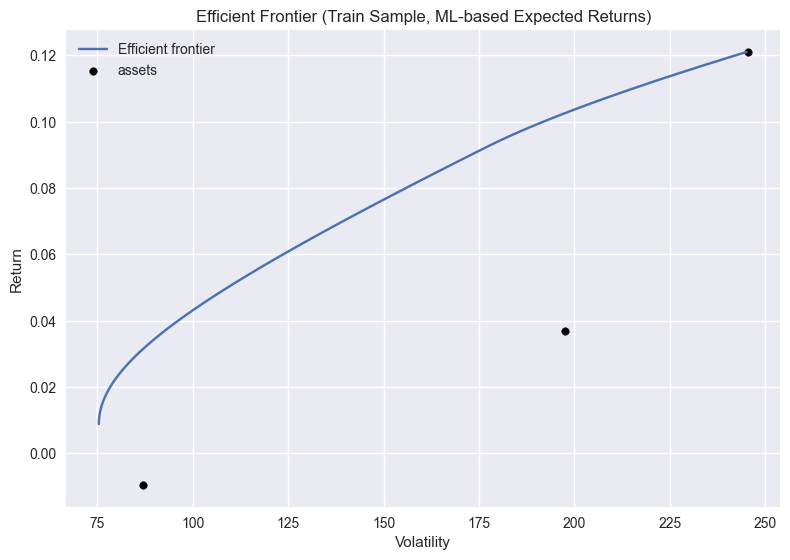

In [40]:
# 8. Efficient Frontier Visualization (Train Sample)

ef_plot = EfficientFrontier(exp_ret_train_ml, cov_train, weight_bounds=(0, 1))
fig, ax = plt.subplots()
plotting.plot_efficient_frontier(ef_plot, ax=ax, show_assets=True)
ax.set_title("Efficient Frontier (Train Sample, ML-based Expected Returns)")
plt.show()


Efficient Frontier (Train Sample, ML-based Expected Returns)

Export for “Production” / Reporting

In [41]:
# 9. Export summary weights and performance tables

summary_weights = pd.DataFrame({
    "MVO_Train": pd.Series(mvo_weights_train),
    "HRP_Train": pd.Series(hrp_weights_train),
})

summary_stats = pd.concat(
    {
        "Train": train_stats.T,
        "Test": test_stats.T,
    },
    axis=0,
)

summary_weights.to_csv("portfolio_weights_mvo_hrp.csv")
summary_stats.to_csv("portfolio_performance_mvo_hrp.csv")

summary_weights, summary_stats


(                MVO_Train  HRP_Train
 Commodities       0.15546   0.105887
 US_Equity         0.08581   0.108848
 US_FixedIncome    0.75873   0.785265,
                     Ann_Return   Ann_Vol    Sharpe  Max_Drawdown
 Train MVO             0.033397  0.052816  0.443002     -0.087649
       HRP             0.037403  0.049058  0.558586     -0.079358
       Equal_Weight    0.061992  0.076407  0.680458     -0.135539
 Test  MVO             0.028865  0.078737  0.239595     -0.171332
       HRP             0.020741  0.077583  0.138445     -0.175790
       Equal_Weight    0.100943  0.096377  0.943619     -0.174680)